In [113]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d

# Venus' Altitudinal Composition Variation

The pressure and temperature variations in Venus' atmosphere are given in ```GGchem/structures/VenusHighResFit.dat```.

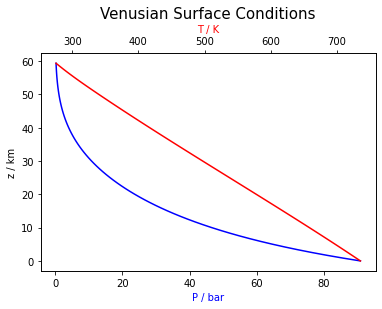

In [116]:
venus_structure = pd.read_csv('../GGchem/structures/VenusHighResFit.dat',
                              delim_whitespace=True,
                             index_col=0)[1:].set_index('z[km]')
max_alt_km = 60
venus_structure = venus_structure[venus_structure.index < max_alt_km]

fg, ax = plt.subplots()
ax2 = ax.twiny()

ax2.plot(
    venus_structure['T[K]'],
    venus_structure.index,
    c='r',
)

ax.plot(
    venus_structure['P[bar]'],
    venus_structure.index,
    c='b',
)

ax2.set_xlabel('T / K', color='r')
ax.set_xlabel('P / bar',
              color='b')
# ax2 = ax.secondary_yaxis(
#     'right', 
#     functions=(
#         interp1d(
#             np.array(venus_structure.index),
#             np.array(venus_structure['P[bar]']),
#             fill_value='extrapolate'
#         ),
#         interp1d(
#             np.array(venus_structure['P[bar]']),
#             np.array(venus_structure.index),
#             fill_value='extrapolate'
#         )
#     )
# )
ax.set_ylabel('z / km')
ax.set_title('Venusian Surface Conditions', fontsize=15);

The highest point on Venus' surface is Skadi Mons, at $12$km; the lowest is Diana Chasma, at $-2$km. The file goes from 0 to 250km, so we will make a new file to interpolate/extrapolate to Venus' surface conditions.

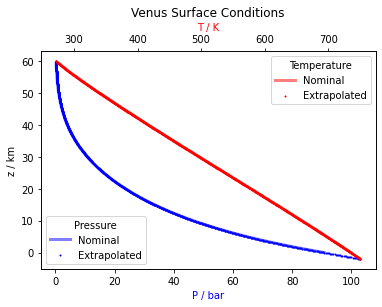

In [117]:
z_km = np.linspace(-2,max_alt_km,1000)
T_K = interp1d(
    venus_structure.index,
    venus_structure['T[K]'],
    fill_value='extrapolate'
)(z_km)
P_bar = interp1d(
    venus_structure.index,
    venus_structure['P[bar]'],
    fill_value='extrapolate'
)(z_km)

fg, ax = plt.subplots()
ax2 = ax.twiny()

ax.scatter(
    P_bar, z_km,
    c='b', s=1, label='Extrapolated'
)
ax.plot(
    venus_structure['P[bar]'], venus_structure.index,
    c='b', alpha=.5, lw=3, label='Nominal'
)
ax2.scatter(
    T_K,z_km,
    c='r', s=1, label='Extrapolated'
)
ax2.plot(
    venus_structure['T[K]'], venus_structure.index,
    c='r', alpha=.5, lw=3, label='Nominal'
)
ax.set_xlabel('P / bar', color='b')
ax2.set_xlabel('T / K', color='r')
ax.set_ylabel('z / km');
ax.set_title('Venus Surface Conditions')

ax.legend(loc='lower left', title='Pressure')
ax2.legend(loc='upper right', title='Temperature');

We now create a file like ```VenusHighResFit.dat```, but with these inter-/extrapolated $p$-$T$ profiles, so that GGchem can run on those conditions.

In [118]:
with open('../GGchem/structures/VenusHighResFit.dat', 'r') as f:
    text = f.read()

extrapolated_profile_filetext = text.split('\n')[0] + '\n' # Headers
extrapolated_profile_filetext += f' {int(len(z_km))}\n' # Number of rows

for i, (z, P, T) in enumerate(zip(z_km, P_bar, T_K)):
    extrapolated_profile_filetext += (' '*(4-len(str(i)))) + f'{str(i)} {z:e} {P:e} {T:e} \n'

with open('../GGchem/structures/VenusSurfaceExtrapFit.dat','w') as f:
    f.write(extrapolated_profile_filetext)

This input file will be used to run GGchem (note you must be in the GGchem folder to run things properly!). The output is put into ```StaticConc.dat```, which I have moved to ```venus/surface_results.dat```. We now look at the results.

In [148]:
filename = f'./surface_results_high_alt.dat'
# Extracting numbers of elements, molecules and condensates
data = open(filename)
_  = data.readline()
dimensions = data.readline()
dimens = np.array(dimensions.split(), dtype=int)
N_elements = dimens[0]
N_molecules = dimens[1]
N_condensates = dimens[2]
# Reading into df
df = pd.read_csv(
    filename,
    delim_whitespace=True,
    header=2,
    index_col=0
)
df['z[km]'] = z_km[:849]
df = df.reset_index().set_index('z[km]')
df

,Tg,nHges,pgas,el,H,C,N,O,F,S,...,epsMg,epsCa,epsAl,epsNa,epsK,epsTi,dust/gas,dustVol/H,Jstar(W),Nstar(W)
z[km],,,,,,,,,,,,,,,,,,,,,
-2.000000,750.6022,7.647086e+16,103049000.0,-300.0,3.157909,-28.167391,-10.526915,-5.270709,-3.695432,3.980908,...,-13.810203,-16.692483,-8.539696,-7.785978,-8.090612,-13.222403,3.345527,-15.165133,-300.0,999999.99999
-1.937938,750.1354,7.623675e+16,102669600.0,-300.0,3.149827,-28.187606,-10.548030,-5.295999,-3.716450,3.983141,...,-13.819207,-16.701440,-8.554477,-7.791933,-8.096876,-13.235900,3.345527,-15.165133,-300.0,999999.99999
-1.875876,749.6686,7.600234e+16,102290200.0,-300.0,3.141721,-28.207902,-10.569173,-5.321295,-3.737483,3.985300,...,-13.828215,-16.710407,-8.569261,-7.797894,-8.103146,-13.249412,3.345527,-15.165133,-300.0,999999.99999
-1.813814,749.2017,7.576765e+16,101910800.0,-300.0,3.133588,-28.228282,-10.590348,-5.346603,-3.758533,3.987384,...,-13.837230,-16.719387,-8.584049,-7.803862,-8.109423,-13.262940,3.345527,-15.165133,-300.0,999999.99999
-1.751752,748.7349,7.553266e+16,101531400.0,-300.0,3.125431,-28.248742,-10.611548,-5.371909,-3.779591,3.989387,...,-13.846247,-16.728376,-8.598836,-7.809833,-8.115704,-13.276479,3.345527,-15.165133,-300.0,999999.99999
-1.689690,748.2680,7.529738e+16,101152000.0,-300.0,3.117247,-28.269291,-10.632781,-5.397226,-3.800667,3.991312,...,-13.855270,-16.737378,-8.613627,-7.815812,-8.121993,-13.290036,3.345527,-15.165133,-300.0,999999.99999
-1.627628,747.8012,7.506173e+16,100772500.0,-300.0,3.109037,-28.289923,-10.654038,-5.422540,-3.821750,3.993151,...,-13.864296,-16.746388,-8.628414,-7.821793,-8.128285,-13.303602,3.345528,-15.165133,-300.0,999999.99999
-1.565566,747.3343,7.482587e+16,100393100.0,-300.0,3.100799,-28.310645,-10.675328,-5.447863,-3.842851,3.994908,...,-13.873328,-16.755411,-8.643206,-7.827782,-8.134585,-13.317186,3.345528,-15.165133,-300.0,999999.99999
-1.503504,746.8675,7.458970e+16,100013700.0,-300.0,3.092535,-28.331453,-10.696643,-5.473182,-3.863958,3.996578,...,-13.882363,-16.764443,-8.657994,-7.833775,-8.140889,-13.330781,3.345528,-15.165133,-300.0,999999.99999


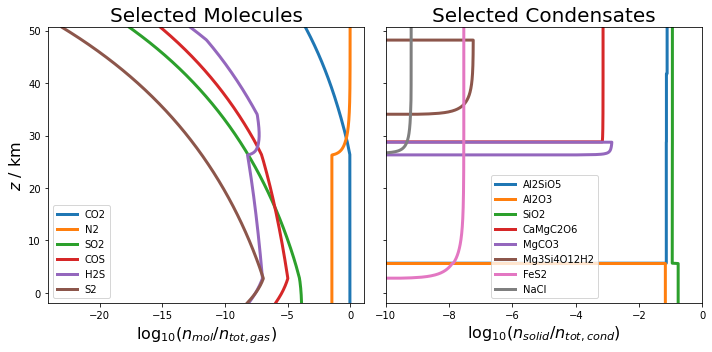

In [163]:
important_molecules = [
    'CO2','N2',
    'SO2','COS','H2S','S2',
#     'CO','H2O','H2','HCL','HF',#'Ar','Ne',
#     'H2SO4'
]
selected_condensates = [
    'Al2SiO5','Al2O3','SiO2',
    'CaMgC2O6','MgCO3','Mg3Si4O12H2',
    'FeS2',
    'NaCl',
#     'MgF2','MgSiO3',
#     'CaAl2Si2O8',
#     'NaAlSi3O8','KAlSi3O8','CaSO4',
#     'Fe2O3','Fe3O4','FeO',
#     'TiO2','Mn3Al2Si3O12'
]

def concentration(molecule, df, N_elements, N_molecules):
    """
    Returns the concentrations of a particular species, as a function of T, from a given df
    """
    return 10**(
        df[molecule] - np.log10(
            np.sum(
                10**df[
                    df.columns[3: 4+N_elements+N_molecules] # including e-, gaseous elements, gaseous molecules
                ],
                axis=1
            )
        )
    )
def condensed_mole_fraction(condensate, df, N_elements, N_molecules, N_condensates):
    """
    Returns the molar fractions of condensed species
    """
    return 10**(
        df[f'n{condensate}'] - np.log10(np.sum(10**df[df.columns[4+N_elements+N_molecules+N_condensates:
                                                                 4+N_elements+N_molecules+2*N_condensates]],
                                               axis=1
                                              )
                                       )
    )

fg, axs = plt.subplots(1,2,figsize=(10,5),
                      sharey=True)
ax = axs[0]
for molecule in important_molecules:
    concs = np.log10(concentration(molecule, df, N_elements, N_molecules))
    ax.plot(
        concs,
        df.index,
        label=molecule,
        lw=3
)
ax.legend(important_molecules, fontsize=10)
ax.set_xlabel('$\log_{10} (n_{mol} / n_{tot, gas})$', fontsize=16)
ax.set_ylabel('$z$ / km', fontsize=16);
ax.set_ylim([
    np.min(df.index.tolist()),
    np.max(df.index.tolist())
])
ax.set_title('Selected Molecules', fontsize=20)

ax = axs[1]
for i, condensate in enumerate(selected_condensates):
    concs = np.log10(condensed_mole_fraction(condensate, df, N_elements, N_molecules, N_condensates))
    ax.plot(
        concs,
        df.index,
        label=condensate,
        lw=3
    )
ax.legend(selected_condensates, fontsize=10)
ax.set_xlabel('$\log_{10} (n_{solid} / n_{tot, cond})$', fontsize=16)
ax.set_xlim([-10,0])
ax.set_ylim([
    np.min(df.index.tolist()),
    np.max(df.index.tolist())
])
ax.set_title('Selected Condensates', fontsize=20);
plt.tight_layout()